데이터셋 : Kaggle - Medical Cost Personal Datasets
[데이터셋 링크](https://www.kaggle.com/datasets/mirichoi0218/insurance)

데이터의 열 특성

- age: age of primary beneficiary

- sex: insurance contractor gender, female, male

- bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

- children: Number of children covered by health insurance / Number of dependents

- smoker: Smoking

- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

- charges: Individual medical costs billed by health insurance

# 데이터 불러오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/데.분.프_실습

/content/drive/MyDrive/데.분.프_실습


In [3]:
pwd

'/content/drive/MyDrive/데.분.프_실습'

In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm

!apt-get -qq install fonts-nanum

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'})

Selecting previously unselected package fonts-nanum.
(Reading database ... 120903 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [5]:
data_path = '/content/drive/MyDrive/데.분.프_실습/'

data =  pd.read_csv(data_path + 'insurance.csv')

# EDA

In [6]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# .info() 함수로 데이터의 각 feature의 Dtype, 데이터 개수, 결측치 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
# charges 열의 데이터 타입 정수로 변환
data.charges = data.charges.astype('int64')

In [9]:
# 결측치 개수 확인
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

결측치는 없는 것으로 확인

In [10]:
# 수치형 변수와 변수형 변수 분리 후 변수형 변수의 값 개수 확인
num_features = ['age', 'bmi', 'children','charges']
cat_features = ['sex', 'smoker','region']

for cat_feature in cat_features:
  print(data[cat_feature].value_counts(), '\n')

male      676
female    662
Name: sex, dtype: int64 

no     1064
yes     274
Name: smoker, dtype: int64 

southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64 



## 범주형 변수 시각화

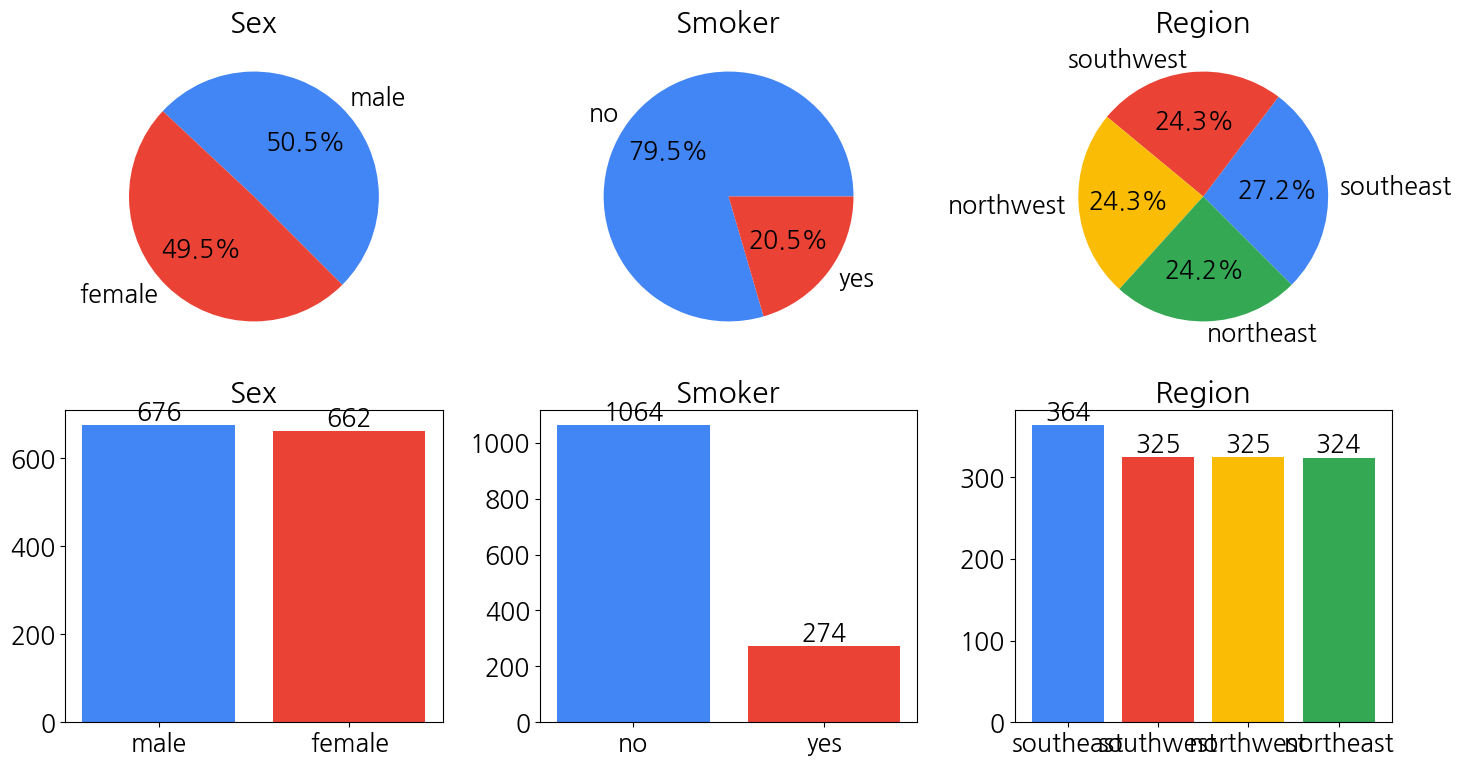

In [11]:
# 범주형 변수 시각화
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# 그래프 색깔 설정
colors = ['#4285f4', '#ea4335', '#fbbc05', '#34a853']

# sex에 대한 파이 차트
gender_counts = data['sex'].value_counts()
axs[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=colors, startangle=-45)
axs[0, 0].set_title('Sex')

# sex에 대한 막대그래프
axs[1, 0].bar(gender_counts.index, gender_counts, color=colors)
axs[1, 0].set_title('Sex')
for i, v in enumerate(gender_counts):
    axs[1, 0].text(i, v + 0.1, str(v), ha='center', va='bottom')

# smoker에 대한 파이 차트
smoker_counts = data['smoker'].value_counts()
axs[0, 1].pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%', colors=colors)
axs[0, 1].set_title('Smoker')

# smoker에 대한 막대그래프
axs[1, 1].bar(smoker_counts.index, smoker_counts, color=colors)
axs[1, 1].set_title('Smoker')
for i, v in enumerate(smoker_counts):
    axs[1, 1].text(i, v + 0.1, str(v), ha='center', va='bottom')

# region에 대한 파이 차트
region_counts = data['region'].value_counts()
axs[0, 2].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', colors=colors, startangle=-45)
axs[0, 2].set_title('Region')

# region에 대한 막대그래프
axs[1, 2].bar(region_counts.index, region_counts, color=colors)
axs[1, 2].set_title('Region')
for i, v in enumerate(region_counts):
    axs[1, 2].text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()

plt.show()

### Sex와 수치형 변수와의 관계 시각화




#### 바이올린 플롯

In [12]:
list_col = data.select_dtypes([np.number]).columns

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Sex ~ Age", "Sex ~ BMI", "Sex ~ Children", "Sex ~ Charges")
    )

for i in range(len(list_col)):
    row = i//2
    col = i%2
    fig.add_trace(go.Violin(y=data[list_col[i]],x=data['sex'], box_visible=True),
                  row=row+1, col=col+1)

fig.show()

#### 히스토그램

In [13]:
list_col = data.select_dtypes([np.number]).columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Sex ~ Age", "Sex ~ BMI", "Sex ~ Children", "Sex ~ Charges")
    )

for i in range(len(list_col)):
    row = i//2
    col = i%2
    fig.add_trace(go.Histogram(y=data[list_col[i]],x=data['sex']),
                  row=row+1, col=col+1)

fig.show()

#### Box plot과 distribution plot

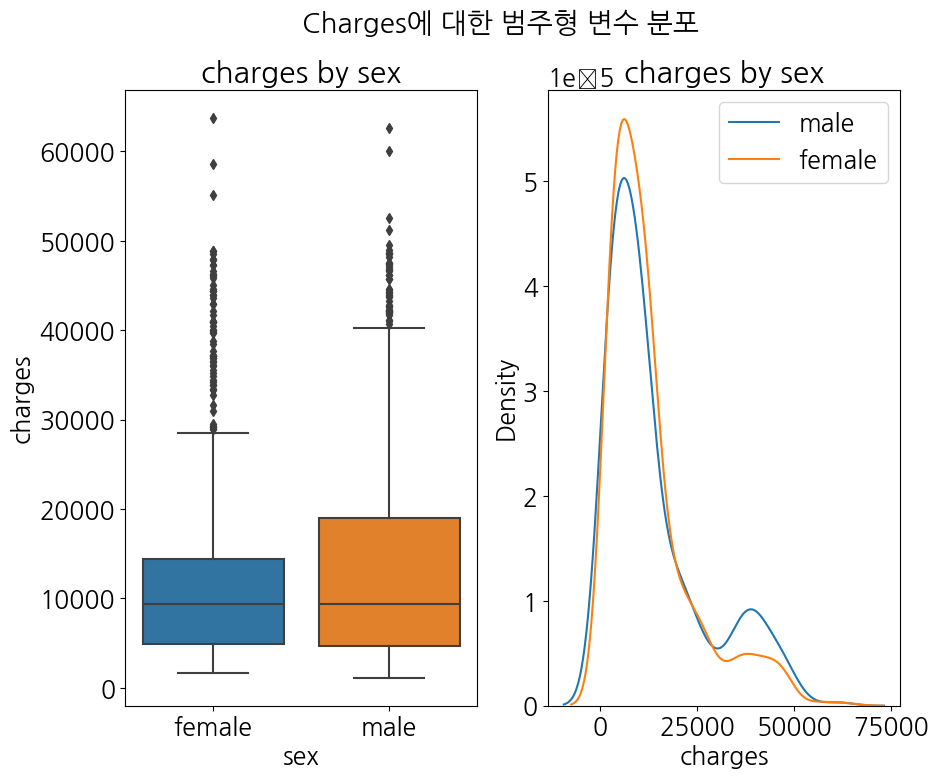

In [14]:
fig, ((ax1, ax2)) = plt.subplots(figsize = (10,8), ncols=2, nrows=1)

# Sex
sns.boxplot(x="sex", y="charges", data=data, ax=ax1)
sns.distplot(data[data['sex'] == 'male']['charges'], ax=ax2, hist=False, label="male")
sns.distplot(data[data['sex'] == 'female']['charges'], ax=ax2, hist=False, label="female")

# Title
fig.suptitle('Charges에 대한 범주형 변수 분포', fontsize=20)
ax1.set_title('charges by sex')
ax2.set_title('charges by sex')

plt.legend()
plt.show()

각 성별의 charges의 Outlier가 많으므로 Outlier제거를 고려

### smoker와 수치형 변수와의 관계 시각화





#### 바이올린 플롯

In [15]:
list_col = data.select_dtypes([np.number]).columns

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Smoker ~ Age", "Smoker ~ BMI", "Smoker ~ Children", "Smoker ~ Charges")
    )

for i in range(len(list_col)):
    row = i//2
    col = i%2
    fig.add_trace(go.Violin(y=data[list_col[i]],x=data['smoker'], box_visible=True),
                  row=row+1, col=col+1)

fig.show()

바이올린 플롯에서 Smoker와 Charges관계에서 담배를 피는 사람들의 Charges가 높은 것을 확인할 수 있다.

#### Box plot과 distribution plot

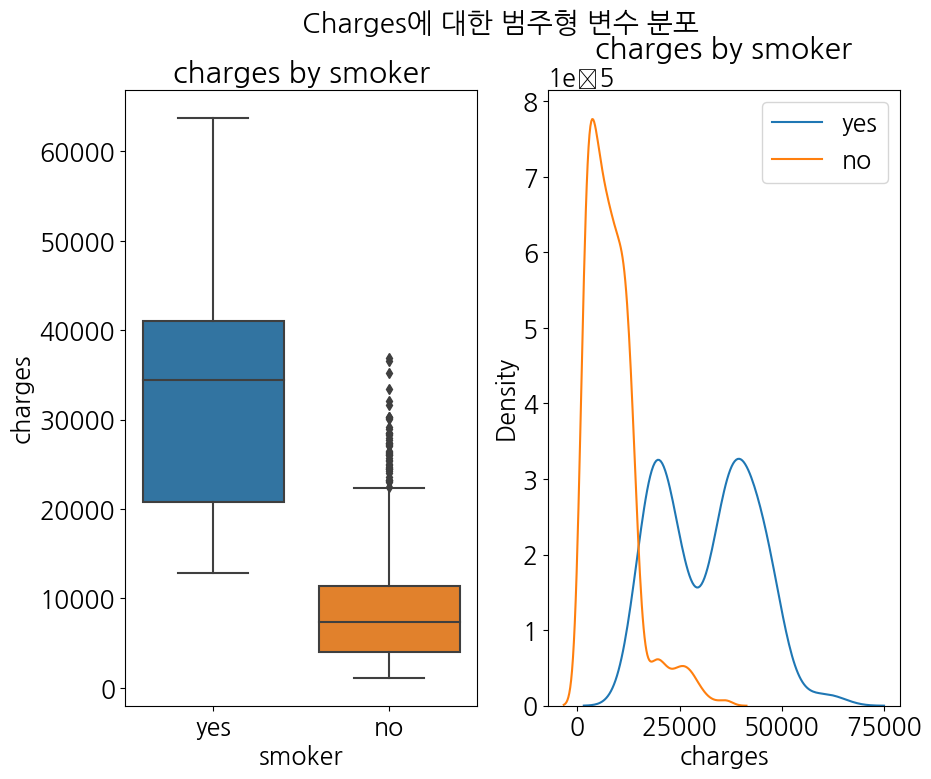

In [16]:
fig, ((ax1, ax2)) = plt.subplots(figsize = (10,8), ncols=2, nrows=1)

# smoker
sns.boxplot(x="smoker", y="charges", data=data, ax=ax1)
sns.distplot(data[data['smoker'] == 'yes']['charges'], ax=ax2, hist=False, label="yes")
sns.distplot(data[data['smoker'] == 'no']['charges'], ax=ax2, hist=False, label="no")

# Title
fig.suptitle('Charges에 대한 범주형 변수 분포', fontsize=20)
ax1.set_title('charges by smoker')
ax2.set_title('charges by smoker')

plt.legend()
plt.show()

smoker=no일 때 이상치 존재를 확인

### region과 수치형 변수와의 관계 시각화





#### 바이올린 플롯

In [17]:
list_col = data.select_dtypes([np.number]).columns

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Region ~ Age", "Region ~ BMI", "Region ~ Children", "Region ~ Charges")
    )

for i in range(len(list_col)):
    row = i//2
    col = i%2
    fig.add_trace(go.Violin(y=data[list_col[i]],x=data['region'], box_visible=True),
                  row=row+1, col=col+1)

fig.show()

#### Box plot과 distribution plot

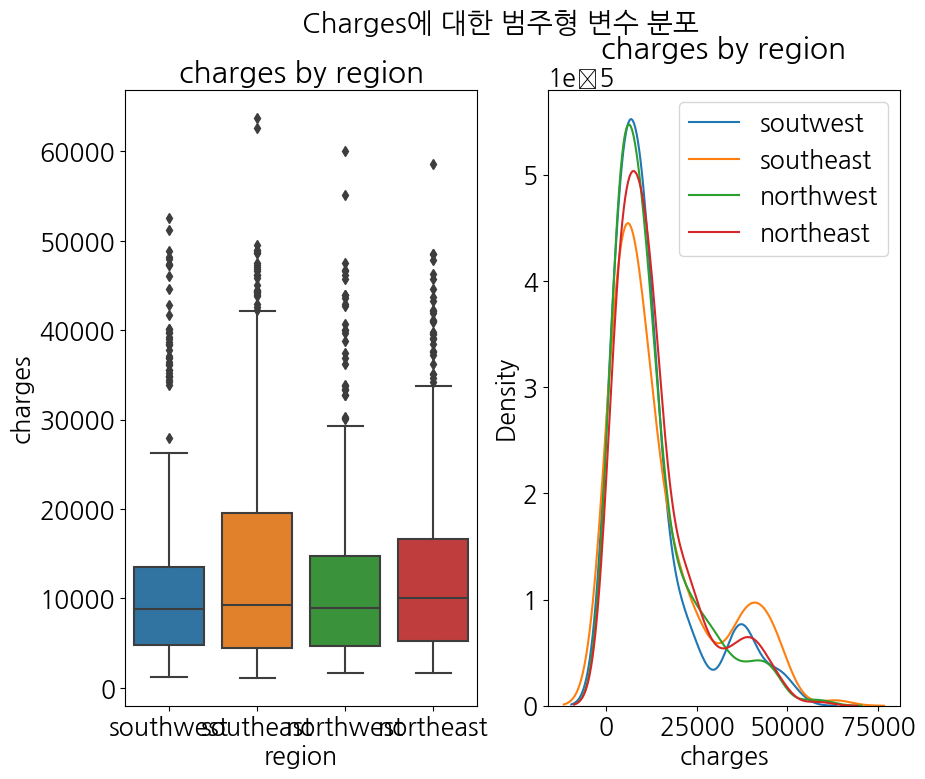

In [18]:
fig, ((ax1, ax2)) = plt.subplots(figsize = (10,8), ncols=2, nrows=1)

# region
sns.boxplot(x="region", y="charges", data=data, ax=ax1)
sns.distplot(data[data['region'] == 'southwest']['charges'], ax=ax2, hist=False, label="soutwest")
sns.distplot(data[data['region'] == 'southeast']['charges'], ax=ax2, hist=False, label="southeast")
sns.distplot(data[data['region'] == 'northwest']['charges'], ax=ax2, hist=False, label="northwest")
sns.distplot(data[data['region'] == 'northeast']['charges'], ax=ax2, hist=False, label="northeast")

# Title
fig.suptitle('Charges에 대한 범주형 변수 분포', fontsize=20)
ax1.set_title('charges by region')
ax2.set_title('charges by region')

plt.legend()
plt.show()

모든 지역에서 이상치 존재 확인

## Cleaning data - 이상치(Outliers) 제거

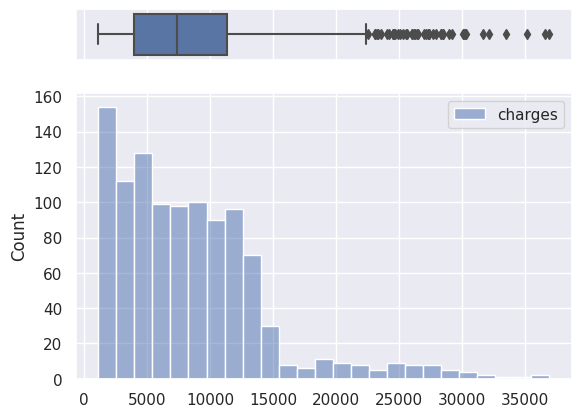

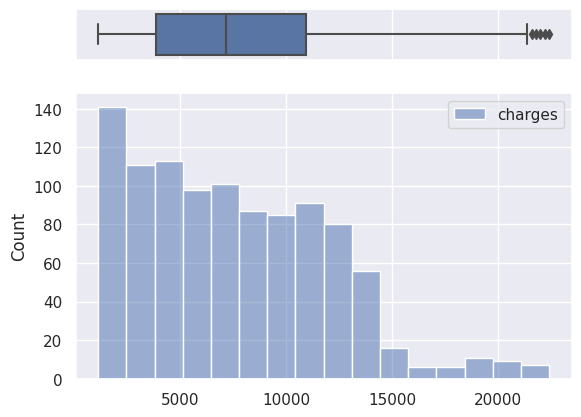

In [19]:
# smoker=no였던 데이터의 이상치를 제거
data_no_charges = pd.DataFrame(data[(data.smoker == 'no')]["charges"])

Q3 = data_no_charges.quantile(0.75)
Q1 = data_no_charges.quantile(0.25)
IQR = Q3-Q1
upper = Q3+(1.5*IQR)
lower = Q1-(1.5*IQR)

remove_outliers = data_no_charges[(data_no_charges.charges > float(lower)) & (data_no_charges.charges < float(upper))]

# 이상치 제거 전 시각화
sns.set(style="darkgrid")
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

sns.boxplot(x='charges', data=data_no_charges, ax=ax_box)
sns.histplot(data_no_charges, color='b', ax=ax_hist, label='not smoke')
ax_box.set(xlabel='')
plt.show()

# 이상치 제거 후 시각화
sns.set(style="darkgrid")
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

sns.boxplot(x='charges', data=remove_outliers, ax=ax_box)
sns.histplot(remove_outliers,color='b',ax=ax_hist, label='not smoke')
ax_box.set(xlabel='')
plt.show()

### charges **vs** variable (다변량 분석 시각화)

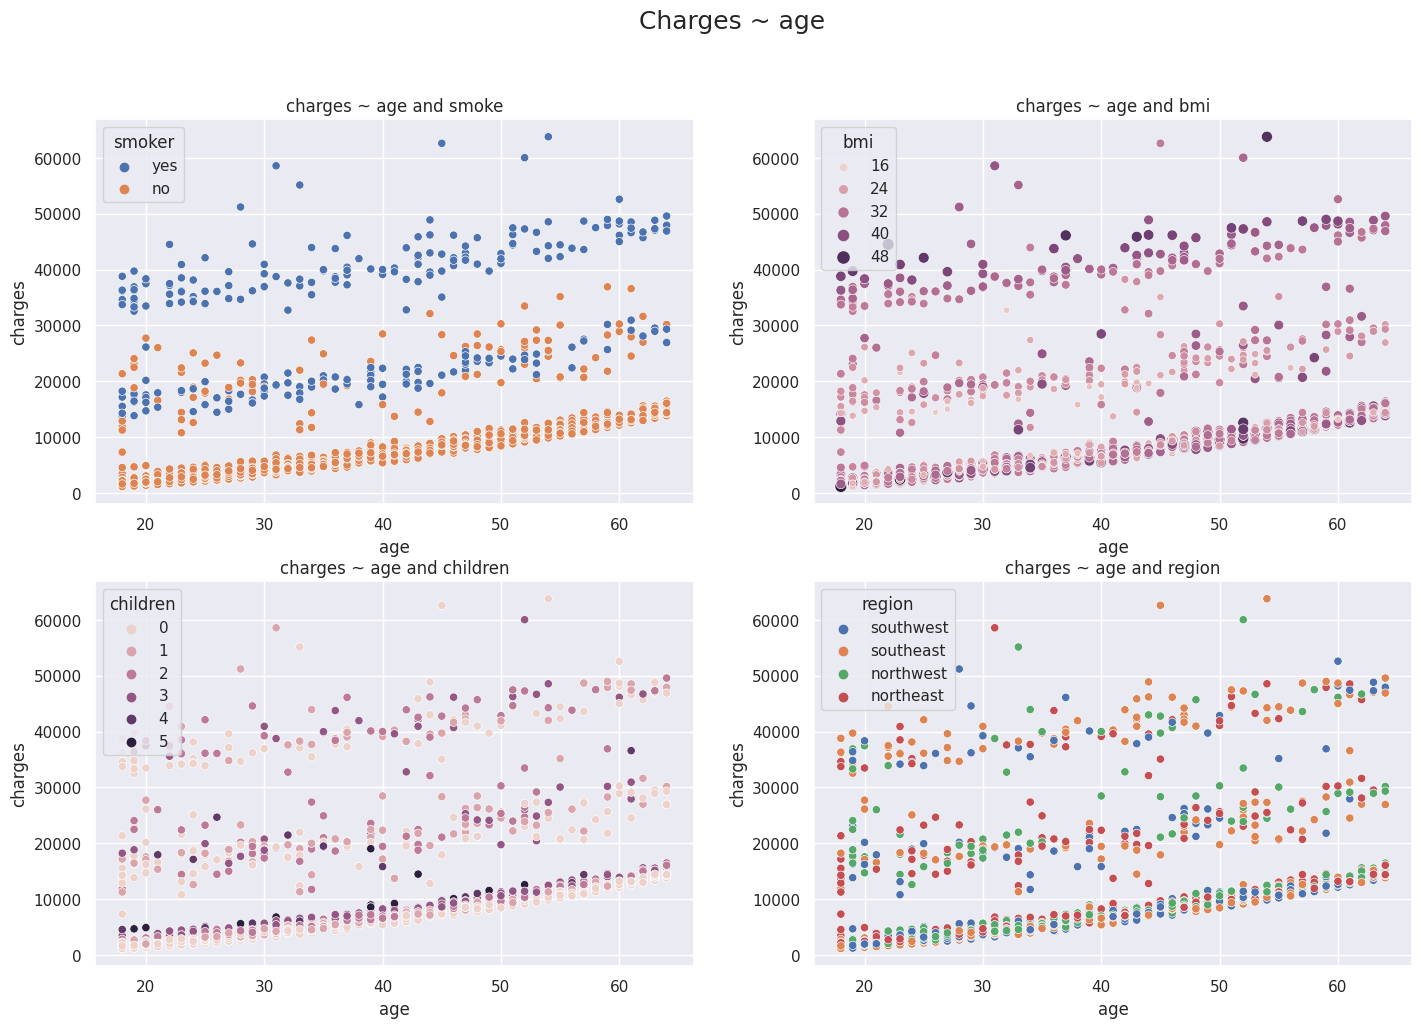

In [20]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize = (17,11), ncols=2, nrows=2, sharex=False, sharey=False)

sns.scatterplot(x="age", y="charges", hue="smoker", data=data, ax=ax1)
sns.scatterplot(x="age", y="charges", hue="bmi", data=data, size="bmi", ax=ax2)
sns.scatterplot(x="age", y="charges", hue="children", data=data, ax=ax3)
sns.scatterplot(x="age", y="charges", hue="region", data=data, ax=ax4)

# Title
fig.suptitle('Charges ~ age', fontsize=18)
ax1.set_title("charges ~ age and smoke")
ax2.set_title("charges ~ age and bmi")
ax3.set_title("charges ~ age and children")
ax4.set_title("charges ~ age and region")
plt.show()

### BMI **vs** variable (다변량 분석 시각화)

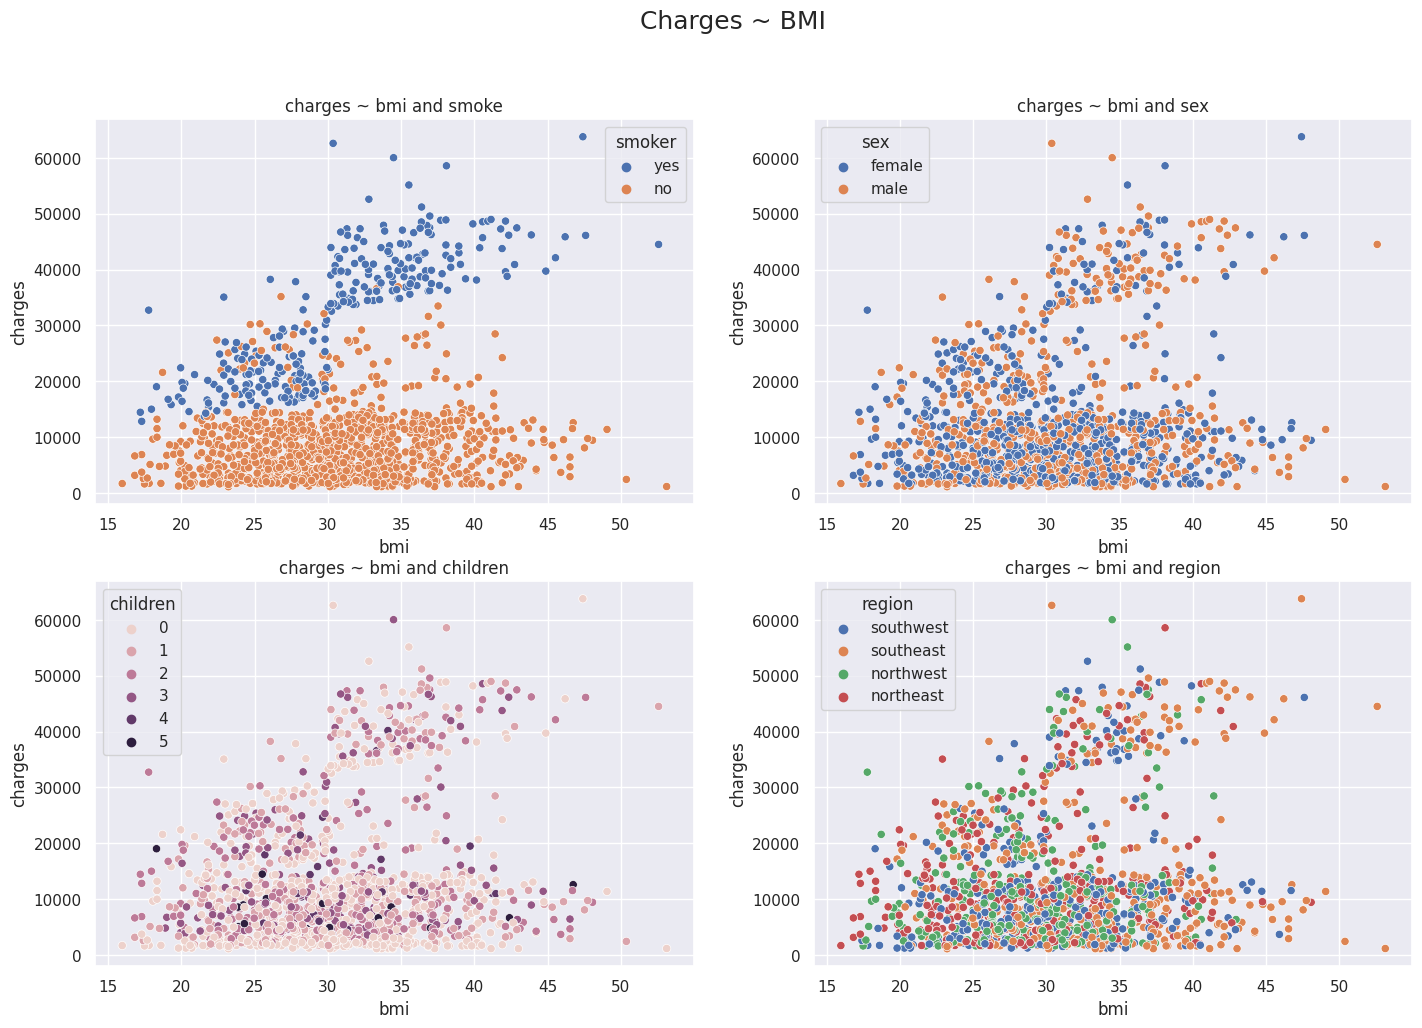

In [21]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize = (17,11), ncols=2, nrows=2, sharex=False, sharey=False)

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=data, ax=ax1)
sns.scatterplot(x="bmi", y="charges", hue="sex", data=data, ax=ax2)
sns.scatterplot(x="bmi", y="charges", hue="children", data=data, ax=ax3)
sns.scatterplot(x="bmi", y="charges", hue="region", data=data, ax=ax4)

# Config Titles
fig.suptitle('Charges ~ BMI', fontsize=18)
ax1.set_title("charges ~ bmi and smoke")
ax2.set_title("charges ~ bmi and sex")
ax3.set_title("charges ~ bmi and children")
ax4.set_title("charges ~ bmi and region")

plt.show()

## Data Preprocessing

### 범주형 변수 Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

# label encoding
lebel_encoding = LabelEncoder()

# Sex
lebel_encoding.fit(data.sex.drop_duplicates())
data.sex = lebel_encoding.transform(data.sex)

# smoke yes or no
lebel_encoding.fit(data.smoker.drop_duplicates())
data.smoker = lebel_encoding.transform(data.smoker)

# region
lebel_encoding.fit(data.region.drop_duplicates())
data.region = lebel_encoding.transform(data.region)


encoding_df = pd.concat([data.sex, data.smoker, data.region], axis=1)
encoding_df.head()

,sex,smoker,region
0,0,1,3
1,1,0,2
2,1,0,2
3,1,0,1
4,1,0,1


# 데이터의 Feature Descripsion

- **age**: 나이 - min=18, max=64

- **sex**: 성별

> female=0

> male=1

- **bmi**: 체질량지수, 정상범위: 18.5 ~ 24.9, min=15.96, max=53.13

- **children**: 건강보험 적용 자녀 수(부양 가족 수) - 0, 1, 2, 3, 4, 5

- **smoker**: 흡연 여부

> yes=1

> no=0

- **region**: 미국 보험 수혜자 거주지역

> southeast : 2

> southwest : 3

> northwest : 1

> northeast : 0

- **charges**: 건강보험에 청구하는 개인 진료비 - min=1121.87390, max=63770.428010

# Encoding
일반적으로 변동성이 큰 범주형 변수는 원핫인코더 등을 사용하여 가장 잘 인코딩된다.

그러나 region의 경우에는 나열되는 특별한 순서가 없기 때문에 아무것도 바뀌지 않기 때문에 레이블 인코더만 사용하면 큰 의미가 없음.

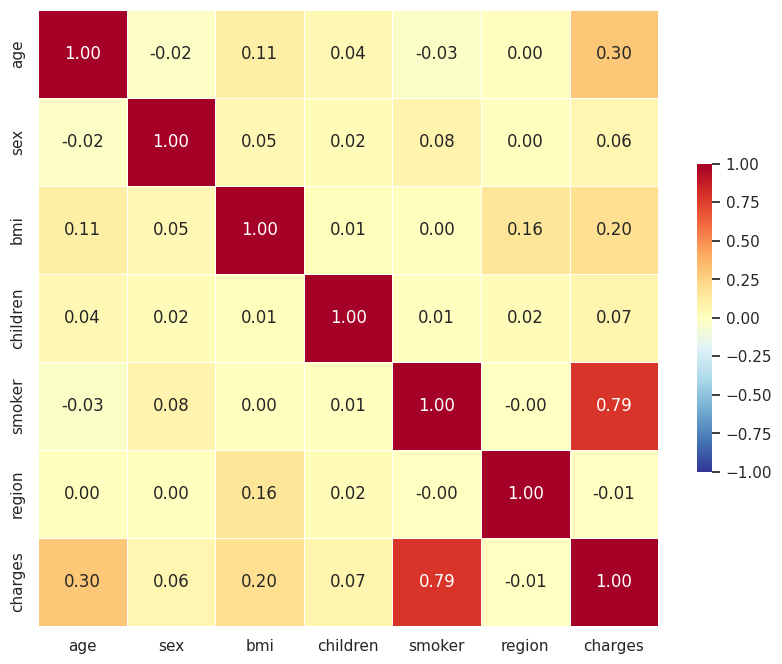

In [23]:
# 상관관계 계수 - 히트맵 시각화
f, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(data.corr(),
            cmap = 'RdYlBu_r',
            fmt=".2f",
            ax=ax,
            mask=np.zeros_like(data.corr(), dtype=bool),
            annot = True,   # 실제 값을 표시한다
            linewidths=.5,  # 경계면 실선으로 구분하기
            cbar_kws={"shrink": .5},# 컬러바 크기 절반으로 줄이기
            vmin = -1,vmax = 1   # 컬러바 범위 -1 ~ 1
           )
plt.show()

charges는 smoker에 강한 양의 상관관계를 갖고, age에는 약한 상관관계를 갖는 것을 알 수 있음

In [24]:
data_charges = data.iloc[:,6:7]
print(data_charges.head(3))
print("===========================================", '\n')

data_charges_smoker = data[(data['smoker'] == 1)]
print(data_charges_smoker.head(3))
print("===========================================", '\n')

data_charges_non_smoker = data[(data['smoker'] == 0)]
print(data_charges_non_smoker.head(3))

   charges
0    16884
1     1725
2     4449

    age  sex    bmi  children  smoker  region  charges
0    19    0  27.90         0       1       3    16884
11   62    0  26.29         0       1       2    27808
14   27    1  42.13         0       1       2    39611

   age  sex     bmi  children  smoker  region  charges
1   18    1  33.770         1       0       2     1725
2   28    1  33.000         3       0       2     4449
3   33    1  22.705         0       0       1    21984


In [25]:
# smoker를 기준으로 그룹화
data.groupby('smoker').count()

,age,sex,bmi,children,region,charges
smoker,,,,,,
0,1064,1064,1064,1064,1064,1064
1,274,274,274,274,274,274


Text(0.5, 1.0, 'Distribution of charges for smokers')

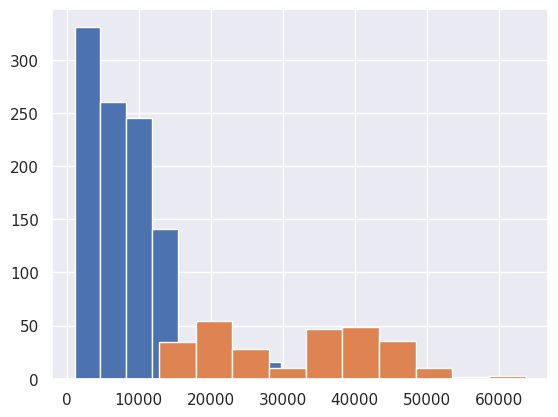

In [26]:
# smoker = 1, smoker = 0 일 때의 히스토그램
plt.hist(data_charges_non_smoker['charges'])

plt.hist(data_charges_smoker['charges'])

ax.set_title('Distribution of charges for smokers')

In [27]:
# smoker=1, smoker=0 일 때 기초통계량 비교
print("data_charges_non_smoker:")
print(data_charges_non_smoker['charges'].describe())
print("===========================================", '\n')

print("data_charges_smoker:")
print(data_charges_smoker['charges'].describe())

data_charges_non_smoker:
count     1064.000000
mean      8433.778195
std       5993.777948
min       1121.000000
25%       3985.500000
50%       7345.000000
75%      11362.250000
max      36910.000000
Name: charges, dtype: float64

data_charges_smoker:
count      274.000000
mean     32049.726277
std      11541.588040
min      12829.000000
25%      20825.750000
50%      34455.500000
75%      41019.000000
max      63770.000000
Name: charges, dtype: float64


In [28]:
# sex를 기준으로 그룹화
data_charges_smoker.groupby('sex').count()

,age,bmi,children,smoker,region,charges
sex,,,,,,
0,115,115,115,115,115,115
1,159,159,159,159,159,159


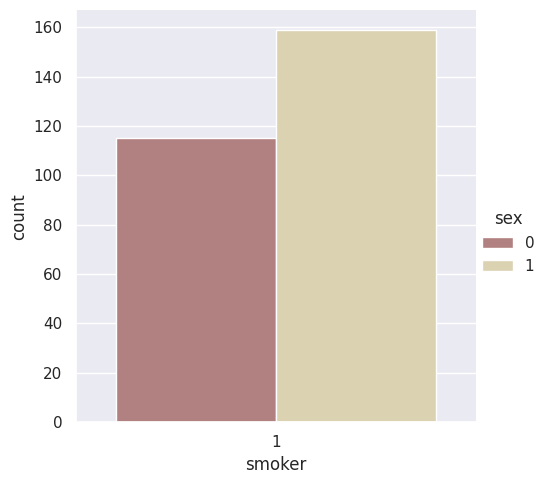

In [29]:
# categorical plot
sns.catplot(x="smoker", hue = 'sex',
            kind="count", palette="pink", data=data_charges_smoker)

In [35]:
# sex=1, sex=0 일 때의 기초 통계량 비교
data_charges_smoker_men = data_charges_smoker[(data_charges_smoker['sex'] == 1)]
data_charges_smoker_women = data_charges_smoker[(data_charges_smoker['sex'] == 0)]

display(data_charges_smoker_men.describe())
print("===============================================================================================", '\n')
display(data_charges_smoker_women.describe())

,age,sex,bmi,children,smoker,region,charges
count,159.000000,159.0,159.000000,159.000000,159.0,159.000000,159.000000
mean,38.446541,1.0,31.504182,1.188679,1.0,1.572327,33041.515723
std,13.751247,0.0,5.952028,1.170144,0.0,1.093474,11202.703390
min,18.000000,1.0,17.290000,0.000000,1.0,0.000000,12829.000000
25%,27.000000,1.0,27.360000,0.000000,1.0,1.000000,21241.000000
50%,38.000000,1.0,31.130000,1.000000,1.0,2.000000,36085.000000
75%,49.500000,1.0,35.565000,2.000000,1.0,2.000000,41797.500000
max,64.000000,1.0,52.580000,4.000000,1.0,3.000000,62592.000000


,age,sex,bmi,children,smoker,region,charges
count,115.000000,115.0,115.000000,115.000000,115.0,115.000000,115.000000
mean,38.608696,0.0,29.608261,1.008696,1.0,1.426087,30678.469565
std,14.217419,0.0,6.663802,1.135516,0.0,1.060130,11907.584583
min,18.000000,0.0,17.195000,0.000000,1.0,0.000000,13844.000000
25%,26.500000,0.0,24.650000,0.000000,1.0,0.500000,19696.000000
50%,39.000000,0.0,28.380000,1.000000,1.0,1.000000,28950.000000
75%,48.500000,0.0,34.352500,2.000000,1.0,2.000000,40918.000000
max,64.000000,0.0,47.600000,5.000000,1.0,3.000000,63770.000000


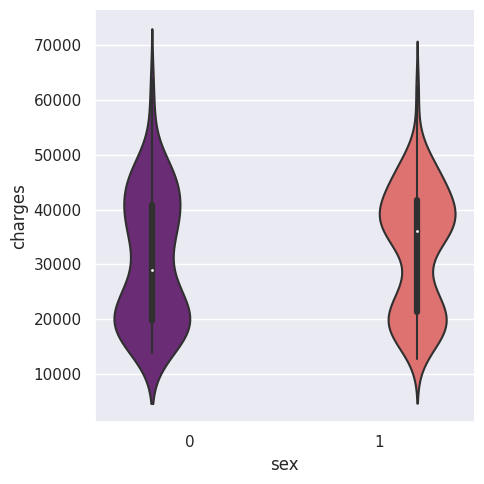

In [36]:
# sex=0, sex=1일 때 charges의 violin plot
sns.catplot(x="sex", y="charges", hue="sex",
            kind="violin", palette='magma', data=data_charges_smoker)

In [37]:
# 각 나이 별로 count한 값을 상위 5개 출력
data_charges_smoker.groupby('age').count().head()

,sex,bmi,children,smoker,region,charges
age,,,,,,
18,12,12,12,12,12,12
19,18,18,18,18,18,18
20,9,9,9,9,9,9
21,2,2,2,2,2,2
22,6,6,6,6,6,6


(array([47., 30., 23., 27., 22., 33., 28., 22., 15., 27.]),
 array([18. , 22.6, 27.2, 31.8, 36.4, 41. , 45.6, 50.2, 54.8, 59.4, 64. ]),
 <BarContainer object of 10 artists>)

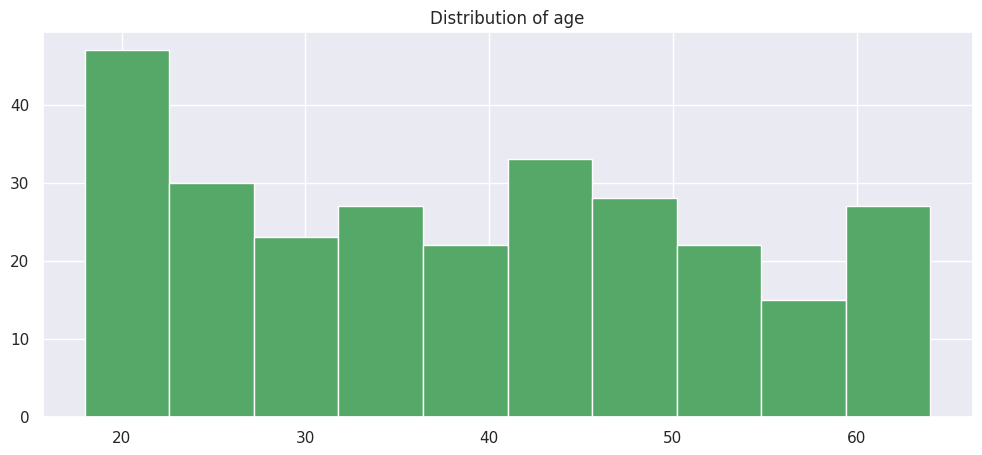

In [38]:
plt.figure(figsize=(12,5))
plt.title("Distribution of age")
plt.hist(data_charges_smoker['age'], color = 'g')

In [39]:
# 빈도 확인
print(data_charges_smoker['age'].mode())
print("=====================================", '\n')

dx = data_charges_smoker.groupby('age').charges.agg(['sum','mean'])
display(dx.head(5))

0    19
Name: age, dtype: int64



,sum,mean
age,,
18,305678,25473.166667
19,486011,27000.611111
20,221164,24573.777778
21,33301,16650.500000
22,224237,37372.833333


Text(0.5, 1.0, 'The number of male and female smokers (18-19 years old)')

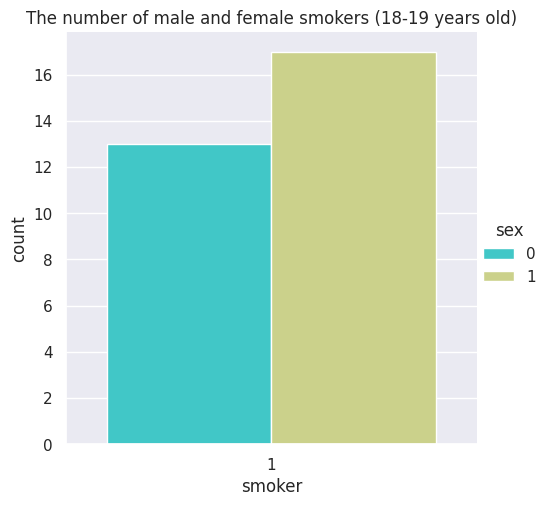

In [41]:
# 20세 미만의 흡연자의 남녀 분포
sns.catplot(x="smoker", kind="count",hue = 'sex', palette="rainbow",
            data=data_charges_smoker[(data.age < 20)])

plt.title("The number of male and female smokers (18-19 years old)")

# 결론

### 선형회귀분석을 이용한 Charges 예측

In [121]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [122]:
X = data.drop(['charges'], axis = 1)
y = data['charges']

# 데이터 Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state =42)

# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_predict = model.predict(X_test)

# R2 Score
print(r2_score(y_test, y_predict)) # R2 Score

0.7833469128363173


train 데이터셋을 이용해서 test 데이터의 의료비를 선형 회귀법으로 추정한 결과

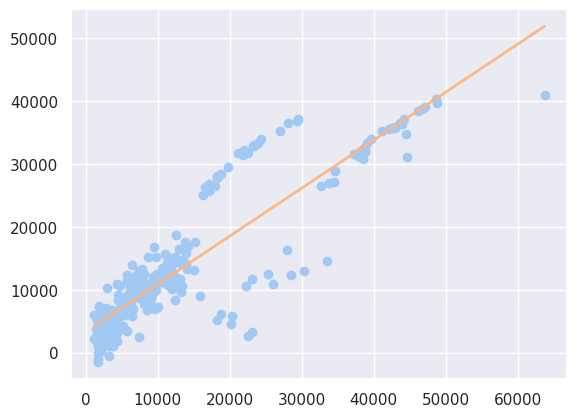

In [123]:
palette = sns.color_palette("pastel")
sns.set_palette(palette)
plt.plot(y_test,y_predict,'o')

m, b = np.polyfit(y_test,y_predict,1)
plt.plot(y_test,m*y_test+b)
plt.show()

In [124]:
# 평가지표
print("Mean Absolute Error: ", mae(y_test,y_predict))
print("Mean Squared Error: ", mse(y_test,y_predict))
print("Root Mean Squared Error: ", (mse(y_test,y_predict))**(1/2))
print("R2 Score: ", r2_score(y_test,y_predict))

Mean Absolute Error:  4186.517167309192
Mean Squared Error:  33635048.98585214
Root Mean Squared Error:  5799.573172730225
R2 Score:  0.7833469128363173


### 다항회귀를 적용한 Charges 예측

In [127]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [128]:
x = data.drop(['charges'], axis = 1)
Y = data.charges

# 2차 다항식으로 변환
poly = PolynomialFeatures (degree = 2)
x_poly = poly.fit_transform(x)

# 데이터 split
x_train, x_test, Y_train, Y_test = train_test_split(x_poly, Y, test_size=0.2, random_state = 42)

# 모델 생성, 학습
plr = LinearRegression().fit(x_train,Y_train)

# 예측
Y_pred = plr.predict(x_test)

# R2 Score
print(r2_score(Y_test, Y_pred))

0.8649199538975938


In [129]:
# 평가지표
print("Mean Absolute Error: ", mae(Y_test,Y_pred))
print("Mean Squared Error: ", mse(Y_test,Y_pred))
print("Root Mean Squared Error: ", (mse(Y_test,Y_pred))**(1/2))
print("R2 Score: ", r2_score(Y_test,Y_pred))

Mean Absolute Error:  2876.1329874067164
Mean Squared Error:  20970963.428889487
Root Mean Squared Error:  4579.406449409081
R2 Score:  0.8649199538975938


R2 score도 향상되고, 평가지표의 값도 낮아져 성능이 더 좋음을 확인

### RandomForestRegressor를 이용한 Charges 예측

In [130]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [132]:
X = data.drop(['charges'], axis = 1)
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state =42)

# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 모델 생성
forest = RandomForestRegressor(n_estimators = 100,
                              criterion = 'friedman_mse',
                              random_state = 42,
                              n_jobs = -1,)
forest.fit(X_train,y_train)

forest_pred = forest.predict(X_test)

In [133]:
# 평가지표
print("Mean Absolute Error: ", mae(y_test,forest_pred))
print("Mean Squared Error: ", mse(y_test,forest_pred))
print("Root Mean Squared Error: ", (mse(y_test,forest_pred))**(1/2))
print("R2 Score: ", r2_score(y_test,forest_pred))

Mean Absolute Error:  2528.7052213930347
Mean Squared Error:  21002834.508409303
Root Mean Squared Error:  4582.884954742951
R2 Score:  0.8647146630483933


LinearRegression 보다 성능이 좋음을 확인